# Helmet Detection Dataset Analysis

This notebook focuses on:
- Understanding dataset structure
- Verifying image-label consistency
- Preparing data for training

The dataset follows YOLO format:
- Images and labels are stored separately
- Labels contain bounding box annotations

In [7]:
import os
import glob
import random
import cv2
from collections import Counter
import matplotlib.pyplot as plt

## Dataset Paths

We define paths for train, validation, and test datasets.

In [8]:
# Defining dataset paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "helmet_detection")

# Setting up train, test and validation image and labels directory
image_train_dir = os.path.join(DATA_PATH, "train", "images")
labels_train_dir = os.path.join(DATA_PATH, "train", "labels")

image_test_dir = os.path.join(DATA_PATH, "test", "images")
labels_test_dir = os.path.join(DATA_PATH, "test", "labels")

image_val_dir = os.path.join(DATA_PATH, "valid", "images")
labels_val_dir = os.path.join(DATA_PATH, "valid", "labels")

## Dataset Summary

We check the number of images and labels in each split.

In [9]:
def count_files(img_dir, lbl_dir):
    images = [f for f in os.listdir(img_dir) if not f.startswith(".")]
    labels = [f for f in os.listdir(lbl_dir) if not f.startswith(".")]
    return len(images), len(labels)

for split, img_dir, lbl_dir in [
    ("TRAIN", image_train_dir, labels_train_dir),
    ("VALID", image_val_dir, labels_val_dir),
    ("TEST", image_test_dir, labels_test_dir)
]:
    img_count, lbl_count = count_files(img_dir, lbl_dir)
    print(f"{split}: Images = {img_count}, Labels = {lbl_count}")

TRAIN: Images = 13782, Labels = 13782
VALID: Images = 3962, Labels = 3962
TEST: Images = 2001, Labels = 2001


---

# Annotations Visualization

## Drawing Bounding Boxes

We convert YOLO format to pixel coordinates and draw bounding boxes.
Different colors are used for each class.

In [19]:
CLASS_NAMES = {
    0 : "Helmet",
    1 : "No Helmet"
}

def draw_boxes(image_path, label_path):
    image = cv2.imread(image_path)
    h, w, _ = image.shape

    if not os.path.exists(label_path):
        return image

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cls = int(cls)
        label = CLASS_NAMES.get(cls, "Unknown")
        
        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(image, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    return image

## Visualizing Random Samples

We randomly sample images and display annotations.

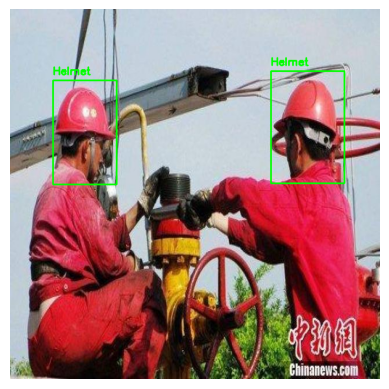

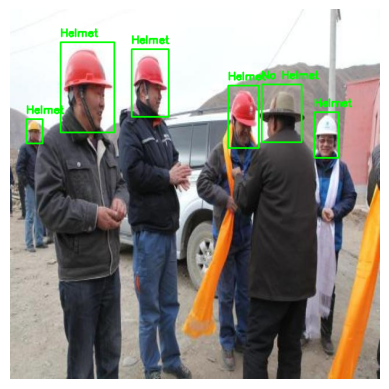

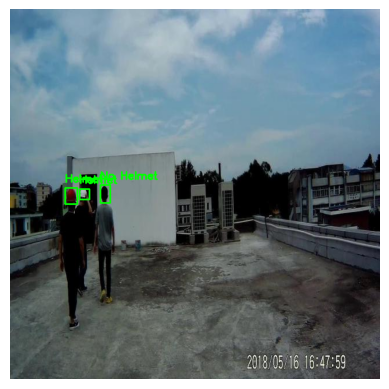

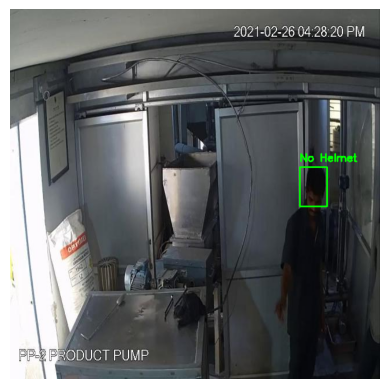

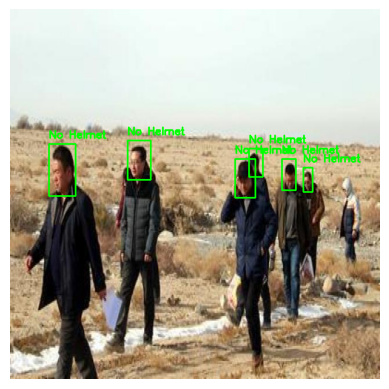

In [26]:
image_files = os.listdir(image_train_dir)

for _ in range(5):
    img_name = random.choice(image_files)

    img_path = os.path.join(image_train_dir, img_name)
    lbl_path = os.path.join(
        labels_train_dir,
        os.path.splitext(img_name)[0] + ".txt"
    )

    img = draw_boxes(img_path, lbl_path)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()